# Crypto Market Sentiment vs Bitcoin Price Movement

## Objective 
This project analyzes whether cryptocurrency news sentiment is associated with short-term Bitcoin price movement.

## Tools Used
- Python
- Pandas
- Matplotlib
- TextBlob
- yfinance

## Data Sources
 - Bitcoin historical market data from yfinance
 - Cryptocurrency news headlines dataset

In [1]:
# Import core libraries for data handling and analysis
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import TextBlob for sentiment analysis of text
from textblob import TextBlob

# Import yfinance to download Bitcoin historical price data
import yfinance as yf

## Load Cryptocurrency News Dataset
This dataset contains cryptocurrency-related news headlines and timestamps.

In [2]:
# Read the crypto news dataset from the data folder
news = pd.read_csv("data/crypto_news.csv")

# Display the first 5 rows to inspect the dataset
news.head()

,Date,Headlines
0,5/11/2021 4:42,Bitcoin price is consolidating near the USD 62...
1,5/11/2021 8:15,Congress could finally approve or reject the m...
2,5/11/2021 10:24,Bitcoin increasingly becoming a political inst...
3,5/11/2021 16:58,There is still potential for the price of bitc...
4,5/11/2021 21:00,'Several companies' are looking to Latin Ameri...


## Inspect Dataset Structure
Check the column names and size of the dataset before cleaning.

In [3]:
# Show the column names in the dataset
print("Columns:")
print(news.columns)

# Show the number of rows and columns
print("\nShape:")
print(news.shape)

Columns:
Index(['Date', 'Headlines'], dtype='object')

Shape:
(11295, 2)


## Clean the News Dataset
Convert the date column into a usable format, remove time information, rename columns, and handle missing values.

In [4]:
# Convert the Date column into datetime format
news['Date'] = pd.to_datetime(news['Date'])

# Keep only the date part and remove the time part
# This is important because Bitcoin price data will be matched at daily level
news['Date'] = news['Date'].dt.date

# Rename the Headlines column to Headline for easier use
news = news.rename(columns={'Headlines': 'Headline'})

# Check for missing values in each column
print(news.isnull().sum())

# Remove rows where the headline is missing
news = news.dropna(subset=['Headline'])

# Preview cleaned data
news.head()

Date        0
Headline    0
dtype: int64


,Date,Headline
0,2021-05-11,Bitcoin price is consolidating near the USD 62...
1,2021-05-11,Congress could finally approve or reject the m...
2,2021-05-11,Bitcoin increasingly becoming a political inst...
3,2021-05-11,There is still potential for the price of bitc...
4,2021-05-11,'Several companies' are looking to Latin Ameri...


## Sentiment Analysis
Calculate a sentiment polarity score for each news headline using TextBlob.

Sentiment score range:
- Negative: less than 0
- Neutral: equal to 0
- Positive: greater than 0

In [5]:
# Define a function to calculate sentiment polarity from text
def get_sentiment(text):
    # Convert text to string and return polarity score
    return TextBlob(str(text)).sentiment.polarity

# Apply the sentiment function to every headline
news['Sentiment_Score'] = news['Headline'].apply(get_sentiment)

# Display the updated dataset
news.head()

,Date,Headline,Sentiment_Score
0,2021-05-11,Bitcoin price is consolidating near the USD 62...,0.050000
1,2021-05-11,Congress could finally approve or reject the m...,0.000000
2,2021-05-11,Bitcoin increasingly becoming a political inst...,0.316667
3,2021-05-11,There is still potential for the price of bitc...,0.250000
4,2021-05-11,'Several companies' are looking to Latin Ameri...,0.068182


## Create Sentiment Labels
Convert sentiment scores into easier-to-read categories:
Positive, Negative, or Neutral.

In [6]:
# Define a function to assign sentiment labels based on polarity score
def label_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Create a new column with sentiment labels
news['Sentiment_Label'] = news['Sentiment_Score'].apply(label_sentiment)

# Check the first few rows
news.head()

,Date,Headline,Sentiment_Score,Sentiment_Label
0,2021-05-11,Bitcoin price is consolidating near the USD 62...,0.050000,Positive
1,2021-05-11,Congress could finally approve or reject the m...,0.000000,Neutral
2,2021-05-11,Bitcoin increasingly becoming a political inst...,0.316667,Positive
3,2021-05-11,There is still potential for the price of bitc...,0.250000,Positive
4,2021-05-11,'Several companies' are looking to Latin Ameri...,0.068182,Positive


## Aggregate Sentiment by Day
Multiple headlines may exist for the same day, so calculate the average daily sentiment score.

In [7]:
# Group headlines by date and calculate the average sentiment score for each day
daily_sentiment = news.groupby('Date')['Sentiment_Score'].mean().reset_index()

# Add a sentiment label to each day based on the average sentiment score
daily_sentiment['Sentiment_Label'] = daily_sentiment['Sentiment_Score'].apply(label_sentiment)

# Preview the daily sentiment dataset
daily_sentiment.head()

,Date,Sentiment_Score,Sentiment_Label
0,2021-05-11,0.136970,Positive
1,2021-06-11,0.000000,Neutral
2,2021-08-11,-0.002399,Negative
3,2021-09-11,0.160417,Positive
4,2021-09-12,0.056250,Positive


## Load Bitcoin Historical Price Data
Download Bitcoin price data and calculate daily returns.

In [8]:
# Download Bitcoin price data from Yahoo Finance
btc = yf.download("BTC-USD", start="2023-01-01", end="2025-01-01")

# Preview raw Bitcoin price data
btc.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2023-01-01,16625.080078,16630.439453,16521.234375,16547.914062,9244361700
2023-01-02,16688.470703,16759.343750,16572.228516,16625.509766,12097775227
2023-01-03,16679.857422,16760.447266,16622.371094,16688.847656,13903079207
2023-01-04,16863.238281,16964.585938,16667.763672,16680.205078,18421743322
2023-01-05,16836.736328,16884.021484,16790.283203,16863.472656,13692758566


## Prepare Bitcoin Dataset
Keep relevant columns, calculate daily return, and align date format for merging.

In [9]:
# If the downloaded dataset has multi-level columns, flatten them
if isinstance(btc.columns, pd.MultiIndex):
    btc.columns = [col[0] if col[0] != '' else col[1] for col in btc.columns]

# Reset the index so Date becomes a normal column
btc = btc.reset_index()

# Keep only the columns needed for this project
btc = btc[['Date', 'Close']]

# Calculate daily percentage return of Bitcoin closing price
btc['Daily_Return'] = btc['Close'].pct_change() * 100

# Convert Date column to date only for daily merging
btc['Date'] = pd.to_datetime(btc['Date']).dt.date

# Remove rows with missing values caused by percentage change calculation
btc = btc.dropna()

# Preview cleaned Bitcoin dataset
btc.head()

,Date,Close,Daily_Return
1,2023-01-02,16688.470703,0.381295
2,2023-01-03,16679.857422,-0.051612
3,2023-01-04,16863.238281,1.099415
4,2023-01-05,16836.736328,-0.157158
5,2023-01-06,16951.968750,0.684411


## Merge Sentiment and Bitcoin Data
Combine daily sentiment scores with Bitcoin daily price and return data.

In [10]:
# Merge Bitcoin data with daily sentiment using the Date column
merged = pd.merge(btc, daily_sentiment, on='Date', how='inner')

# Check the shape of the merged dataset
print("Merged dataset shape:", merged.shape)

# Preview the merged dataset
merged.head()

Merged dataset shape: (483, 5)


,Date,Close,Daily_Return,Sentiment_Score,Sentiment_Label
0,2023-01-02,16688.470703,0.381295,0.173462,Positive
1,2023-01-03,16679.857422,-0.051612,0.019301,Positive
2,2023-01-04,16863.238281,1.099415,-0.026389,Negative
3,2023-01-05,16836.736328,-0.157158,0.011742,Positive
4,2023-01-06,16951.968750,0.684411,0.109967,Positive


## Exploratory Analysis
Analyze how sentiment is related to Bitcoin daily returns.

In [11]:
# Calculate correlation between same-day sentiment score and daily return
correlation_same_day = merged[['Daily_Return', 'Sentiment_Score']].corr()
print("Correlation between same-day sentiment and daily return:")
print(correlation_same_day)

Correlation between same-day sentiment and daily return:
                 Daily_Return  Sentiment_Score
Daily_Return         1.000000         0.028909
Sentiment_Score      0.028909         1.000000


In [12]:
# Create next-day return column to test whether today's sentiment
# has any relationship with tomorrow's Bitcoin return
merged['Next_Day_Return'] = merged['Daily_Return'].shift(-1)

# Calculate correlation between sentiment score and next-day return
correlation_next_day = merged[['Sentiment_Score', 'Next_Day_Return']].corr()
print("Correlation between sentiment and next-day return:")
print(correlation_next_day)

Correlation between sentiment and next-day return:
                 Sentiment_Score  Next_Day_Return
Sentiment_Score         1.000000         0.060003
Next_Day_Return         0.060003         1.000000


In [13]:
# Calculate average Bitcoin daily return for each sentiment category
avg_return_by_sentiment = merged.groupby('Sentiment_Label')['Daily_Return'].mean()
print("Average daily return by sentiment label:")
print(avg_return_by_sentiment)

Average daily return by sentiment label:
Sentiment_Label
Negative   -0.157932
Neutral    -0.053079
Positive    0.335170
Name: Daily_Return, dtype: float64


## Visualization 1: Bitcoin Closing Price Over Time
This chart shows the overall Bitcoin closing price trend.

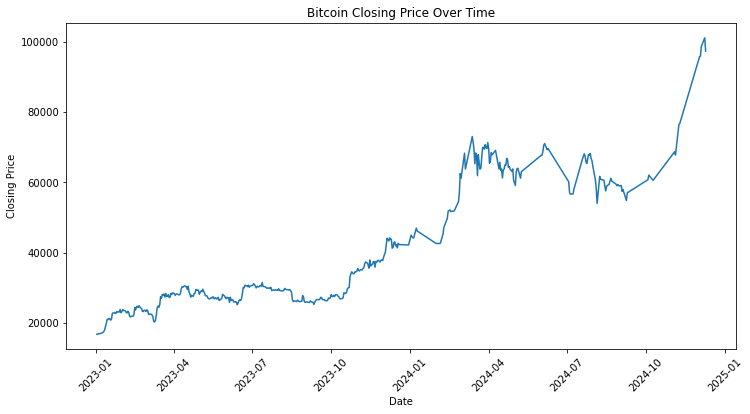

In [14]:
# Plot Bitcoin closing price over time
plt.figure(figsize=(12, 6))
plt.plot(merged['Date'], merged['Close'])

# Add chart title and axis labels
plt.title('Bitcoin Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')

# Rotate date labels for readability
plt.xticks(rotation=45)

# Display the chart
plt.show()

Bitcoin prices exhibit a clear upward trajectory, rising from lower levels in early 2023 to significantly higher levels toward the end of the period. This suggests increasing market demand and growing investor interest in cryptocurrency.

Despite the general upward trend, several short-term fluctuations and corrections are visible, highlighting the high volatility characteristic of cryptocurrency markets.

A strong rally toward the end of the period indicates a phase of bullish market momentum. Understanding this price trend provides important context for evaluating how cryptocurrency news sentiment may align with Bitcoin market movements.

## Visualization 2: Daily Sentiment Score Over Time
This chart shows how average sentiment changes over time.

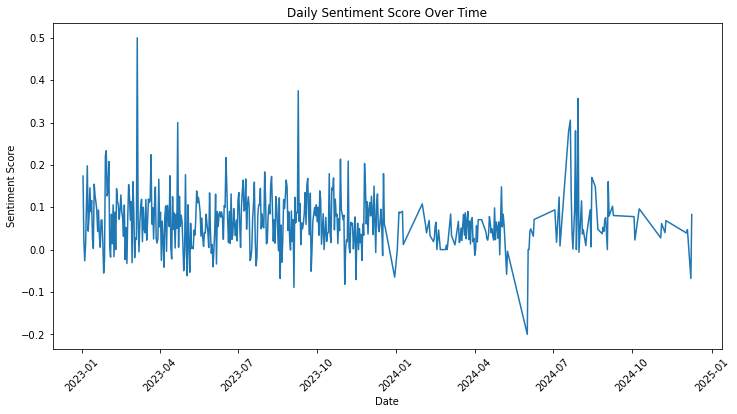

In [15]:
# Plot daily sentiment score over time
plt.figure(figsize=(12, 6))
plt.plot(merged['Date'], merged['Sentiment_Score'])

# Add chart title and axis labels
plt.title('Daily Sentiment Score Over Time')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')

# Rotate date labels for readability
plt.xticks(rotation=45)

# Display the chart
plt.show()

Most sentiment scores remain slightly above zero, indicating that news coverage during the observed period was generally mildly positive toward Bitcoin.

The frequent fluctuations in sentiment reflect the fast-moving nature of cryptocurrency markets, where investor perception can change quickly in response to news events.

A noticeable negative spike appears around mid-2024, suggesting a period of pessimistic news coverage or increased market uncertainty. 

However, sentiment quickly recovers afterward, indicating renewed optimism in the market. Toward the end of the period, sentiment stabilizes at a moderately positive level, suggesting balanced market expectations.

## Visualization 3: Sentiment Score vs Bitcoin Daily Return
This scatter plot helps examine whether sentiment and return move together.

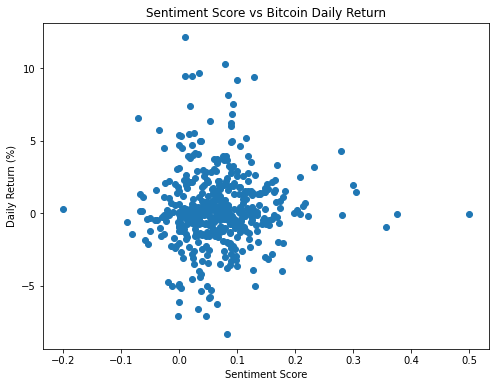

In [16]:
# Create scatter plot of sentiment score against Bitcoin daily return
plt.figure(figsize=(8, 6))
plt.scatter(merged['Sentiment_Score'], merged['Daily_Return'])

# Add chart title and axis labels
plt.title('Sentiment Score vs Bitcoin Daily Return')
plt.xlabel('Sentiment Score')
plt.ylabel('Daily Return (%)')

# Display the chart
plt.show()

The points are widely scattered without a clear linear pattern, suggesting that the relationship between news sentiment and same-day Bitcoin returns is relatively weak.

While some higher sentiment scores coincide with positive returns, many observations show mixed outcomes, indicating that sentiment alone is not a strong predictor of short-term price movement.

Additionally, the wide spread of daily returns reflects the high volatility characteristic of cryptocurrency markets. This suggests that Bitcoin price movements are influenced by multiple factors beyond news sentiment.

## Visualization 4: Average Return by Sentiment Category
This chart compares average Bitcoin returns for positive, neutral, and negative sentiment days.

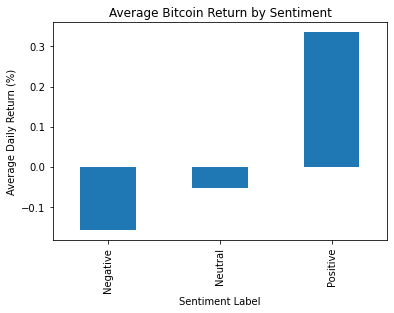

In [17]:
# Calculate average return by sentiment label and plot as bar chart
merged.groupby('Sentiment_Label')['Daily_Return'].mean().plot(kind='bar')

# Add title and labels
plt.title('Average Bitcoin Return by Sentiment')
plt.xlabel('Sentiment Label')
plt.ylabel('Average Daily Return (%)')

# Display the chart
plt.show()

The chart shows that average Bitcoin returns differ across sentiment categories.

Positive sentiment days exhibit the highest average returns, suggesting that optimistic cryptocurrency news coverage may coincide with stronger market performance.

Neutral sentiment days show slightly negative average returns, indicating that when news sentiment is balanced or uncertain, Bitcoin price movement tends to be weaker.

Negative sentiment days display the lowest average returns, suggesting that pessimistic news sentiment may coincide with downward price pressure in the market.

Overall, the results indicate that sentiment categories reflect general market mood and may provide useful context when analyzing cryptocurrency price movements.

## Visualization 5: Rolling Sentiment Trend

This chart shows the 7-day rolling average of sentiment scores.  
A rolling average smooths daily fluctuations and helps identify overall sentiment trends in the crypto market.

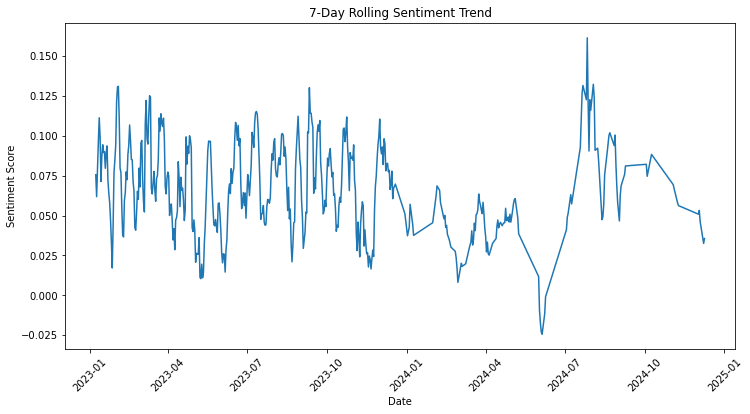

In [18]:
# Calculate a 7-day rolling average of sentiment scores
merged['Rolling_Sentiment'] = merged['Sentiment_Score'].rolling(window=7).mean()

# Plot the rolling sentiment trend
plt.figure(figsize=(12,6))
plt.plot(merged['Date'], merged['Rolling_Sentiment'])

plt.title('7-Day Rolling Sentiment Trend')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')

plt.xticks(rotation=45)

plt.show()

The 7-day rolling sentiment trend indicates that cryptocurrency news sentiment remained generally positive during the observed period. 

Although sentiment fluctuates frequently, reflecting the fast-paced nature of crypto news cycles, most sentiment scores remain above zero, suggesting an overall optimistic tone in market coverage.

A noticeable drop in sentiment appears around mid-2024, likely corresponding to negative market developments or regulatory concerns. However, sentiment quickly recovers afterward, indicating renewed investor confidence and positive market news.

Toward the end of the period, sentiment stabilizes at a moderately positive level, suggesting a balanced market outlook.

## Export Processed Dataset

After completing the sentiment analysis and merging it with Bitcoin price data, the final dataset is exported as a CSV file.

Saving the processed dataset allows the results of the analysis to be reused for further analysis, visualization, or modeling without repeating the entire data preparation process.

The exported dataset contains the combined Bitcoin market data and sentiment analysis results used throughout this project.

In [19]:
# Save the merged dataset to a CSV file for future use
merged.to_csv("btc_sentiment_analysis.csv", index=False)

print("Merged dataset saved successfully.")

Merged dataset saved successfully.


## Key Findings

- Bitcoin showed high short-term volatility during the analysis period.
- News sentiment was mostly neutral to mildly positive.
- The relationship between sentiment and same-day Bitcoin return was weak.
- Sentiment showed a slightly different relationship when compared with next-day returns.
- Sentiment may provide useful market context, but it is not sufficient on its own to predict Bitcoin price movement.

## Limitations

- Sentiment was calculated from headlines only, not full news articles.
- TextBlob is a simple sentiment model and may not fully capture financial language.
- Bitcoin prices are influenced by many other factors such as regulation, macroeconomic conditions, and market liquidity.
- This analysis shows association, not causation.

## Future Improvements

- Use VADER or transformer-based sentiment analysis models for better text understanding.
- Include Reddit, X, or other social media sentiment sources.
- Compare Bitcoin with Ethereum and other cryptocurrencies.
- Build a predictive model using sentiment and market features together.